# Orbital Debris Visualizations

This notebook is visualization-only and reads from the SQLite database.

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
#########################################################################################################
# AI Assisted Function: fit_growth_regimes                                                              #
#                                                                                                       #
# What this does                                                                                        #
# - Splits yearly launch data into two regimes using a split year (2014).                      #
# - Fits a linear trend to the legacy period (pre-2014).                                                #
# - Fits an exponential trend to the modern period (post-2014) using a log-space linear fit.            #
# - Returns both fitted segments and key growth metrics.                                                #
#                                                                                                       #
# Why AI assistance was used                                                                            #
# - I understand the analysis goal (compare pre/post growth behavior),                                  #
#   but needed help structuring a clean reusable function for the two-regime fit workflow.              #
#                                                                                                       #
# AI (GitHub Copilot, GPT-5.3-Codex) helped draft the function structure and equations.                 #
#                                                                                                       #
#########################################################################################################
def fit_growth_regimes(df, split_year=2014, y_col='objects_launched'):
    pre = df[df['launch_year'] <= split_year].copy()
    post = df[df['launch_year'] > split_year].copy()

    # Legacy regime: linear fit  y = m_pre * year + b_pre
    m_pre, b_pre = np.polyfit(pre['launch_year'], pre[y_col], 1)
    pre['trend_linear'] = m_pre * pre['launch_year'] + b_pre

    # Modern regime: exponential fit  y = a_exp * exp(b_exp * year)
    # Implemented by fitting log(y) linearly in year, then transforming back
    post_fit = post[post[y_col] > 0].copy()
    b_exp, a_log = np.polyfit(post_fit['launch_year'], np.log(post_fit[y_col]), 1)
    a_exp = np.exp(a_log)
    post['trend_exponential'] = a_exp * np.exp(b_exp * post['launch_year'])

    # Doubling time from exponential rate: ln(2)/b
    doubling_time = np.log(2) / b_exp
    return pre, post, m_pre, b_exp, doubling_time


In [3]:
def load_query_result(query_name):
    file_path = f'../data/clean/queries/{query_name}.parquet'
    return pd.read_parquet(file_path)

# Set the Palette (High Contrast Neon)
sns.set_palette("plasma") 

# Set the Background (Deep Space Black)
plt.style.use('dark_background')

plt.rcParams.update({
    "grid.alpha": 0.2,            # Faint, non-intrusive grid
    "axes.facecolor": "black",    # No grey haze in plot area
    "figure.facecolor": "black",  # No grey haze in outer area
    "text.color": "white",        # High contrast text
    "axes.labelcolor": "white",   # Axis labels
    "xtick.color": "white",       # Ticks
    "ytick.color": "white",
    "legend.facecolor": "black",  # Legend background
    "legend.edgecolor": "white"   # Legend border
})

### Primary Question 1: Growth and Decoupling Baseline
The year 2014 is frequently identified in space industry analyses as a pivotal year marking the end of a relatively stagnant period and the beginning of a rapid, exponential rise in satellite launches, paticuarlly in Low-Earth-Orbit (LEO). 

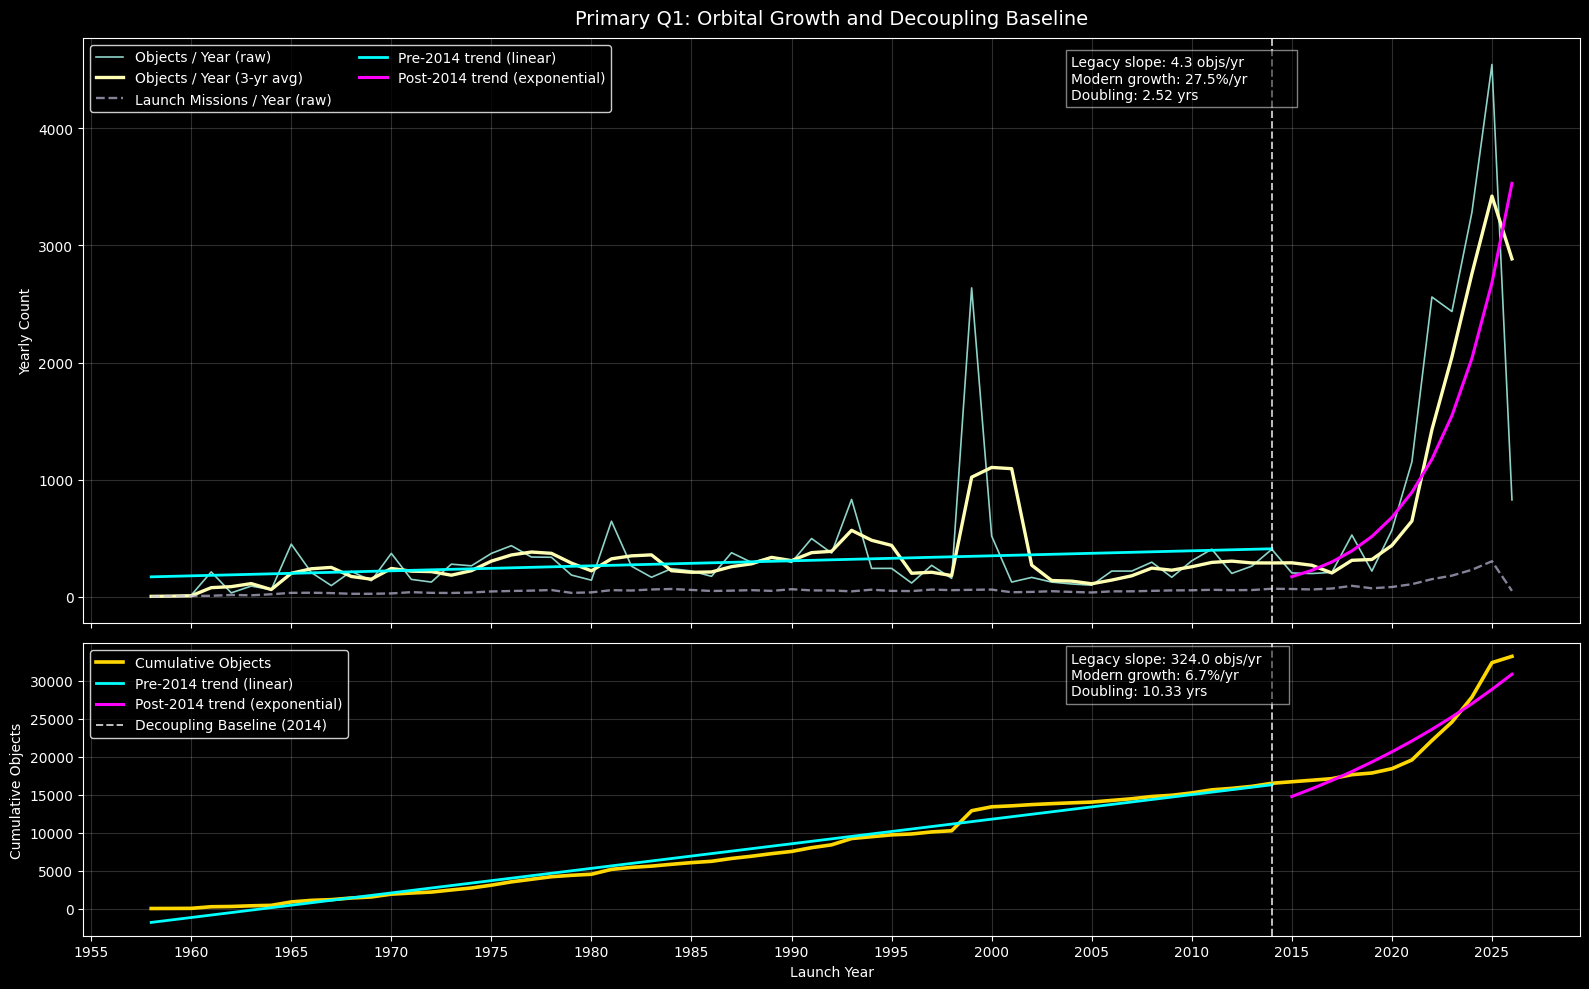

In [4]:
# load our primary question query results from notebook 05.
pq1 = load_query_result('pq1_launch_trend').reset_index().copy()

pq1['objects_3yr_avg'] = pq1['objects_launched'].rolling(3, min_periods=1).mean()

# Define the split year for decoupling legacy and modern growth regimes.
split_year = 2014

# Fit growth regimes for both raw yearly counts and cumulative counts to compare trends and metrics.
pre, post, m_pre, b_exp, doubling_time_years = fit_growth_regimes(pq1, split_year=split_year)
pre_cum, post_cum, m_pre_cum, b_exp_cum, doubling_time_cum = fit_growth_regimes(pq1, split_year=split_year, y_col='cumulative_objects')

# figure with two vertically stacked subplots.
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(16, 10),
    sharex=True,
    # top chart gets more vertical space, 2:1 ratio, it has more data to display
    gridspec_kw={'height_ratios': [2, 1]}
)

# Top graph lineplots.

# Raw yearly counts of objects launched.
sns.lineplot(
    data=pq1,
    x='launch_year',
    y='objects_launched',
    linewidth=1.2,
    ax=ax1,
    label='Objects / Year (raw)'    
)

# Smoothed 3-year rolling average to highlight trends and reduce noise.
sns.lineplot(
    data=pq1,
    x='launch_year',
    y='objects_3yr_avg',
    linewidth=2.4,
    ax=ax1,
    label='Objects / Year (3-yr avg)'
)

sns.lineplot(
    data=pq1,
    x='launch_year',
    y='launch_missions',
    linewidth=1.7,
    linestyle='--',
    alpha=0.7,
    ax=ax1,
    label='Launch Missions / Year (raw)'
)

# Linear trend for pre-2014 data (legacy)
sns.lineplot(
    data=pre,
    x='launch_year',
    y='trend_linear',
    ax=ax1,
    color='cyan',
    linewidth=2.0,
    label='Pre-2014 trend (linear)'
)

# Exponential trend for post-2014 data (modern)
sns.lineplot(
    data=post,
    x='launch_year',
    y='trend_exponential',
    ax=ax1,
    color='magenta',
    linewidth=2.2,
    label='Post-2014 trend (exponential)'
)

# Vertical line for decoupling baseline
ax1.axvline(split_year, color='white', linestyle='--', alpha=0.75, linewidth=1.4)

# Text box with growth metrics
# I prefer to format the f string this way for better readability in the code, it all shows the same in the plot.
ax1.text(
    0.66, 0.97,
    f'Legacy slope: {m_pre:,.1f} objs/yr \
    \nModern growth: {b_exp:.1%}/yr      \
    \nDoubling: {doubling_time_years:.2f} yrs',
    transform=ax1.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(facecolor='black', edgecolor='white', alpha=0.5)
)

ax1.set_title('Primary Q1: Orbital Growth and Decoupling Baseline', fontsize=14, pad=10)
ax1.set_ylabel('Yearly Count')
ax1.grid(alpha=0.18)
ax1.legend(loc='upper left', ncol=2, frameon=True)

# bottom graph lineplot
# here we plot the cumulative objects launched which helps smooth out the year to year noise
# and illistrate the long term growth trends more clearly, especially the exponential growth in the modern era.

# Cumulative objects lineplot
sns.lineplot(
    data=pq1,
    x='launch_year',
    y='cumulative_objects',
    color='gold',
    linewidth=2.6,
    ax=ax2,
    label='Cumulative Objects'
)

# Cumulative objects linear trend (legacy)
sns.lineplot(
    data=pre_cum,
    x='launch_year',
    y='trend_linear',
    ax=ax2,
    color='cyan',
    linewidth=2.0,
    label='Pre-2014 trend (linear)'
)

# Cumulative objects exponential trend (modern)
sns.lineplot(
    data=post_cum,
    x='launch_year',
    y='trend_exponential',
    ax=ax2,
    color='magenta',
    linewidth=2.2,
    label='Post-2014 trend (exponential)'
)

# Vertical line for decoupling baseline
ax2.axvline(split_year, color='white', linestyle='--', alpha=0.75, linewidth=1.4, label='Decoupling Baseline (2014)')

# Text box with growth metrics
# I prefer to format the f string this way for better readability in the code, it all shows the same in the plot.
ax2.text(
    0.66, 0.97,
    f'Legacy slope: {m_pre_cum:,.1f} objs/yr \
    \nModern growth: {b_exp_cum:.1%}/yr      \
    \nDoubling: {doubling_time_cum:.2f} yrs',
    transform=ax2.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(facecolor='black', edgecolor='white', alpha=0.5)
)


ax2.set_xlabel('Launch Year')
ax2.set_ylabel('Cumulative Objects')
ax2.grid(alpha=0.18)
ax2.legend(loc='upper left', frameon=True)

# Set x-axis ticks to every 5 years for better readability
ax2.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig("../images/launch_trends_pq1.svg", bbox_inches="tight")
plt.savefig("../images/launch_trends_pq1.png", bbox_inches="tight", dpi=300)
plt.show()


### Primary Question 2: High-Risk Object Distribution by Orbit Class and Altitude Band
How are high-risk objects (by velocity and kinetic energy) distributed across orbit classes and altitude bands, especially in the 400 - 600 km LEO?

The high-risk population is overwhelmingly dominated by payloads and rocket bodies, with debris contributing very little to the high-risk count. This suggests that the most dangerous objects in orbit are intact spacecraft and spent rocket stages, rather than fragments of debris. The danger from debris comes mainly from the large number of small, high-velocity fragments that can cause significant damage despite their small size.

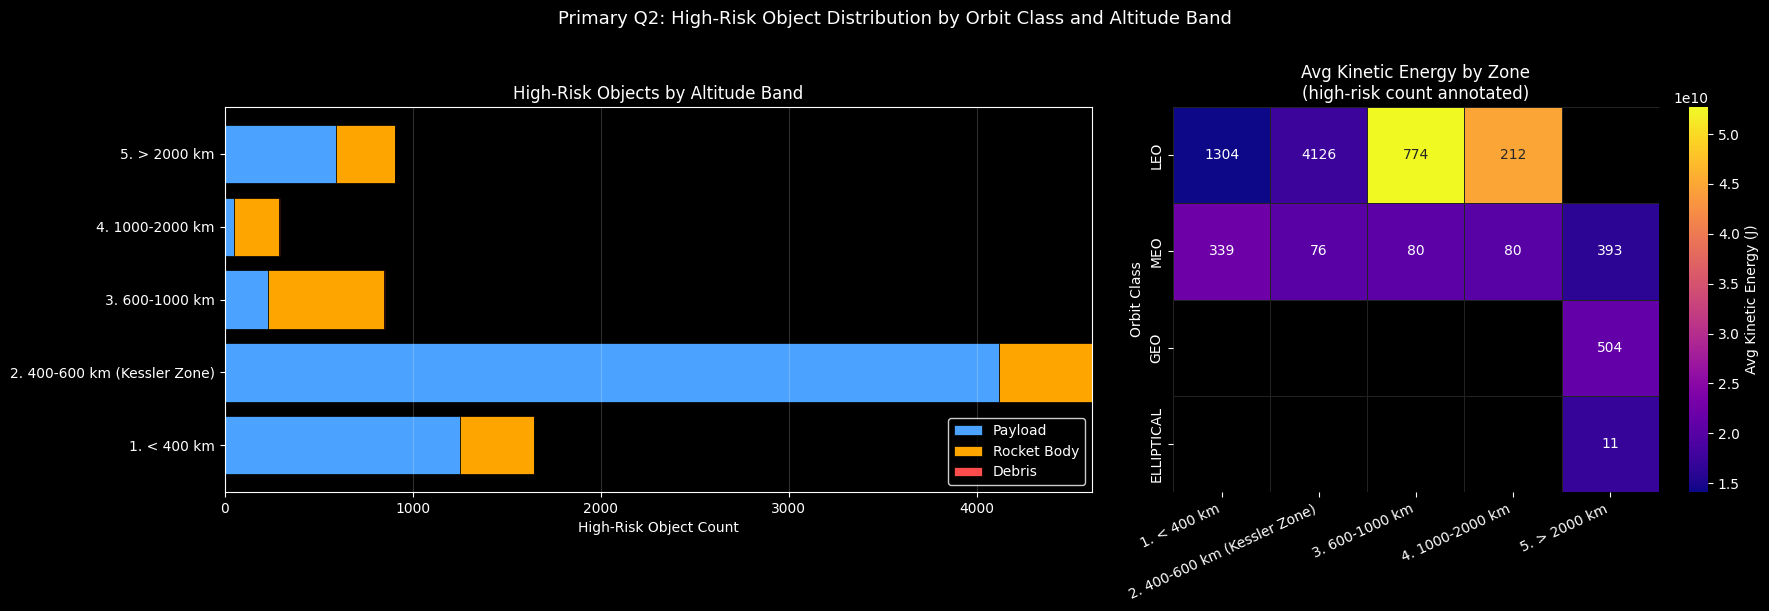

In [ ]:
pq2 = load_query_result('pq2_high_risk').reset_index(drop=True)

# these will match the sql case from the banded cte in our query
altitude_order = [
    "1. < 400 km",
    "2. 400-600 km (Kessler Zone)",
    "3. 600-1000 km",
    "4. 1000-2000 km",
    "5. > 2000 km"
 ]

orbit_order = ['LEO', 'MEO', 'GEO', 'ELLIPTICAL']

# Dictionary: Key(str), Value(tuple(str, str))
# (segment name) : tuple(column in pq2, color for plot)
segments = {
    'Payload':     ('payload_high_risk', '#4CA3FF'),
    'Rocket Body': ('rb_high_risk',      '#FFA500'),
    'Debris':      ('debris_high_risk',  '#FF4C4C'),
}

# Create subset of pq2 that includes only the altitude bands found in our query, ignoring unknown or out
# of range data. This minimizes noise in the bar chart and heatmap from irrelevant altitude bands.
pq2_bar = pq2[pq2['altitude_band'].isin(altitude_order)].copy()

# use pd.Categorical to set the altitude_band order for plotting, then group by altitude_band and sum 
# the high risk counts for each segment type to get totals for the bar chart.
pq2_bar['altitude_band'] = pd.Categorical(pq2_bar['altitude_band'], categories=altitude_order, ordered=True)
pq2_bar = pq2_bar.groupby('altitude_band', observed=True)[['debris_high_risk', 'payload_high_risk', 'rb_high_risk']
    ].sum().reset_index()

# use pivot_table to create a matrix of avg kinetic energy values for the heatmap
# matrix structure: rows = orbit_class, cols = altitude_band, cell value = avg_kinetic_joules
# this works by setting the index to the orbit class and the columns to the altitude band,
# then filling the cells with the mean avg_kinetic_joules for each orbit class / altitude band combination.
heat_data = pq2.pivot_table(index='orbit_class', columns='altitude_band', values='avg_kinetic_joules', aggfunc='mean')
heat_data = heat_data.reindex(index=orbit_order, columns=altitude_order)

# use pivot_table to create a matrix of high risk object counts for the heatmap.
# matrix structure: rows = orbit_class, cols = altitude_band, cell value = high_risk_count
# this works by setting the index to the orbit class and the columns to the altitude band,
# then filling the cells with the sum of high_risk_count for each orbit class / altitude band combination.
heat_counts = pq2.pivot_table(index='orbit_class', columns='altitude_band', values='high_risk_count', aggfunc='sum')
heat_counts = heat_counts.reindex(index=orbit_order, columns=altitude_order)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1.4]})

# Stacked horizontal bar on the left
left = np.zeros(len(pq2_bar))
for label, (col, color) in segments.items():
    ax1.barh(pq2_bar['altitude_band'], pq2_bar[col], left=left, color=color, label=label, edgecolor='black', linewidth=0.5)
    left += pq2_bar[col].values

ax1.set_title('High-Risk Objects by Altitude Band')
ax1.set_xlabel('High-Risk Object Count')
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.18)

# Heatmap on the right
sns.heatmap(
    heat_data,
    ax=ax2,
    cmap='plasma',
    annot=heat_counts.fillna(0).astype(int),
    fmt='d',
    linewidths=0.5,
    linecolor='#222222',
    cbar_kws={'label': 'Avg Kinetic Energy (J)'}
)

ax2.set_title('Avg Kinetic Energy by Zone\n(high-risk count annotated)')
ax2.set_xlabel('')
ax2.set_ylabel('Orbit Class')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Primary Q2: High-Risk Object Distribution by Orbit Class and Altitude Band', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../images/high_risk_distribution_pq2.svg', bbox_inches='tight')
plt.savefig('../images/high_risk_distribution_pq2.png', bbox_inches='tight', dpi=300)
plt.show()